In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# machine learning dependencies
# scaling of data
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
# train/test split
from sklearn.model_selection import train_test_split
# model selection
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
# the KRR model
from sklearn.kernel_ridge import KernelRidge
# linear model
from sklearn.linear_model import LinearRegression, SGDRegressor
# pipeline to streamline modeling pipelines
from sklearn.pipeline import Pipeline
# principal component analysis
from sklearn.decomposition import PCA
# polynomial kernel
from sklearn.metrics.pairwise import polynomial_kernel
# Dummy model as baseline
from sklearn.dummy import DummyClassifier, DummyRegressor
# Variance Threshold for feature selection
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression
# metrics to measure model performance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             mean_absolute_error, mean_squared_error, max_error, mean_absolute_percentage_error)
from sklearn.metrics import r2_score


import xgboost as xgb
import shap

# save/load models
import joblib

# For the permutation importance implementation
from sklearn.metrics import check_scoring
from sklearn.utils import Bunch
from sklearn.utils import check_random_state
from sklearn.utils import check_array


In [38]:
# Load the pre-processed data
df_with_descriptors = pd.read_pickle('processed_data.pkl')

In [39]:
df_with_descriptors.shape

(7973, 20)

In [40]:
RANDOM_SEED = 101
np.random.seed(RANDOM_SEED)

Defining Feature and Target Columns

In [41]:
#Comment out non-utilized features
TARGET_COLS = 'Tc'
FEATURES_COLS = (
    #'FFV',
    'Density',
    'Rg',
    #'Tg', 
    'MW',
    'LogP',
    'TPSA',
    'HBD',
    'HBA',
    'RotBonds',
    'NumHeavyAtoms',
    'NumHeteroatoms',
    'RingCount',
    'NumAromaticRings',
    'FractionCSP3',
    # 'canonical_smiles', # Note: This is a string representation, often needs further featurization (e.g., fingerprints)
    # 'molecule'          # Note: This is an RDKit Mol object, needs conversion to numerical features
)

print(f"Target Columns: {TARGET_COLS}")
print(f"Feature Columns: {FEATURES_COLS}")


Target Columns: Tc
Feature Columns: ('Density', 'Rg', 'MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'NumHeavyAtoms', 'NumHeteroatoms', 'RingCount', 'NumAromaticRings', 'FractionCSP3')


Further Data Processing: duplicate removal, removing rows with NaNs -> Ensures remaining rows have complete data

In [42]:
df_with_descriptors = df_with_descriptors.drop_duplicates()
# Drop rows where 'Tc', 'LogP', 'RotBonds', or 'NumHeavyAtoms' have NaN values
df_with_descriptors = df_with_descriptors.dropna(subset=['Tc','LogP','Rg','RotBonds','Density','NumHeavyAtoms','MW','TPSA','HBD','HBA','NumHeteroatoms','RingCount','NumAromaticRings','FractionCSP3'])
print(f"Number of rows after removing NaN values in specified columns: {df_with_descriptors.shape[0]}")

Number of rows after removing NaN values in specified columns: 531


Target Feature Distribution

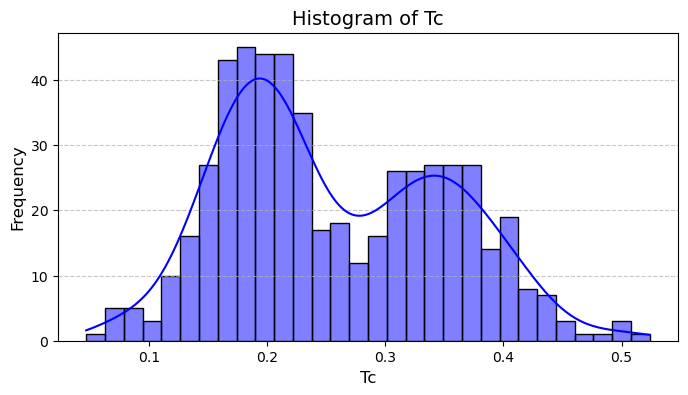

In [43]:
# Plot histogram of the target
plt.figure(figsize=(8, 4))
sns.histplot(df_with_descriptors[TARGET_COLS], kde=True, bins=30, color='blue')

# Add labels and title
plt.xlabel(f"{TARGET_COLS}", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title(f"Histogram of {TARGET_COLS}", fontsize=14)

# Show the plot
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Stratified Data Splitting: Assign High-performing vs Low-performing polymer classes

In [44]:
TARGET_BINARY = "target_binned"  # name of the new binary target column
THRESHOLD = 0.3  # fixed numeric threshold

# Create the binary target on the already cleaned df_with_descriptors for stratification
df_with_descriptors[TARGET_BINARY] = (df_with_descriptors[TARGET_COLS] > THRESHOLD).astype(int)

In [45]:
# Verify we have two classes
print("Class distribution for stratification:")
print(df_with_descriptors[TARGET_BINARY].value_counts())

Class distribution for stratification:
target_binned
0    341
1    190
Name: count, dtype: int64


190 out of 531 samples are high-performing in Tc.

In [46]:
df_train, df_test = train_test_split(
    df_with_descriptors, 
    train_size=0.8,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=df_with_descriptors[TARGET_BINARY] # Stratify using the binary target from cleaned df
)

print(f"df_train shape: {df_train.shape}")
print(f"df_test shape: {df_test.shape}")

df_train shape: (424, 21)
df_test shape: (107, 21)


Find Low-Variance Features

In [47]:
variances = df_train[list(FEATURES_COLS)].var() #FEATURES_COLS is a tuple

# We use a small tolerance for floating-point comparison
redundant_features = variances[variances < 1e-9].index.tolist()

print(f"Features with zero or near-zero variance: {redundant_features}")

print(f"Number of features before: {len(FEATURES_COLS)}")
FEATURES_COLS = [feature for feature in FEATURES_COLS if not feature in redundant_features]
print(f"Number of features after: {len(FEATURES_COLS)}")

Features with zero or near-zero variance: []
Number of features before: 13
Number of features after: 13


Regression Metrics

In [48]:
def get_regression_metrics(model, X, y_true):
    """
    Get a dicionary with regression metrics:

    model: sklearn model with predict method
    X: feature matrix
    y_true: ground truth labels
    """
    # Get predictions from the model using the provided features X
    y_predicted = model.predict(X)

    # Calculate the regression metrics using sklearn.metrics functions
    mae = mean_absolute_error(y_true, y_predicted)
    mse = mean_squared_error(y_true, y_predicted)
    maximum_error = max_error(y_true, y_predicted)
    mape =  mean_absolute_percentage_error(y_true, y_predicted)

    # Store the calculated metrics in a dictionary
    metrics_dict = {
        'mae': mae,
        'mse': mse,
        'max_error': maximum_error,
        'mape': mape
    }

    return metrics_dict

sklearn Linear Model

In [49]:
# Initialize the Linear Regression model
linear_regressor = LinearRegression()

# Train the model on the training data
linear_regressor.fit(df_train[FEATURES_COLS], df_train[TARGET_COLS])

# Evaluate the model on the training and test sets
def linear_regression_metrics(Model, X, y_true):
    """
    Get a dicionary with regression metrics:

    model: sklearn model with predict method
    X: feature matrix
    y_true: ground truth labels
    """
    y_predicted = Model.predict(X)

    mae = mean_absolute_error(y_true,y_predicted)
    mse = mean_squared_error(y_true,y_predicted)
    maximum_error = max_error(y_true,y_predicted)
    mape = mean_absolute_percentage_error(y_true,y_predicted)

    metrics_dict = {
        'mae': mae,
        'mse': mse,
        'max_error': maximum_error,
        'mape': mape
    }

    return metrics_dict

In [50]:
linear_regression_model =[('model',linear_regressor)]
linear_regression_result_test={}
linear_regression_result_train ={}

for model_name, model in linear_regression_model:
    print(f"Calculating metrics for {model_name}")
    linear_regression_result_test[model_name]= linear_regression_metrics(model,df_test[FEATURES_COLS], df_test[TARGET_COLS])
    linear_regression_result_train[model_name] = linear_regression_metrics(model,df_train[FEATURES_COLS], df_train[TARGET_COLS])

# Print the results
print("Linear Regression Results - Train Set:", linear_regression_result_train)
print("Linear Regression Results - Test Set:", linear_regression_result_test)

Calculating metrics for model
Linear Regression Results - Train Set: {'model': {'mae': 0.0332675480993984, 'mse': 0.0020698293048780846, 'max_error': 0.2516790081426114, 'mape': 0.14411787139888768}}
Linear Regression Results - Test Set: {'model': {'mae': 0.040446305596420554, 'mse': 0.0031824684068649826, 'max_error': 0.2815771667983439, 'mape': 0.1751953446713661}}


Linear Model Visualization

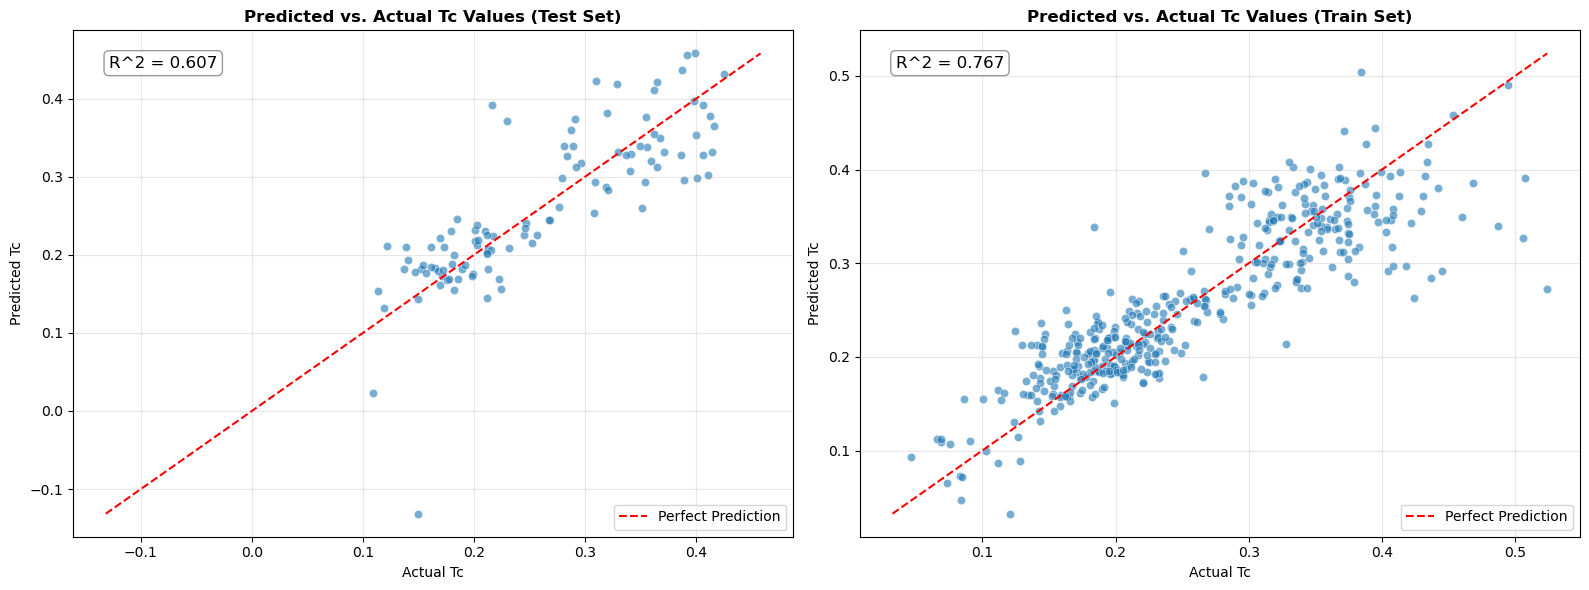

In [51]:
# Get predictions for the test set
y_pred_test = linear_regressor.predict(df_test[FEATURES_COLS])
y_true_test = df_test[TARGET_COLS]

# Get predictions for the train set
y_pred_train = linear_regressor.predict(df_train[FEATURES_COLS])
y_true_train = df_train[TARGET_COLS]

# Calculate R-squared scores
r2_test = r2_score(y_true_test, y_pred_test)
r2_train = r2_score(y_true_train, y_pred_train)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # 1 row, 2 columns

# Plot for Test Set
ax = axes[0]
sns.scatterplot(x=y_true_test, y=y_pred_test, alpha=0.6, ax=ax)
min_val_test = min(y_true_test.min(), y_pred_test.min())
max_val_test = max(y_true_test.max(), y_pred_test.max())
ax.plot([min_val_test, max_val_test], [min_val_test, max_val_test], color='red', linestyle='--', label='Perfect Prediction')
ax.text(0.05, 0.95, f'R^2 = {r2_test:.3f}', transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=1, alpha=0.8))
ax.set_title('Predicted vs. Actual Tc Values (Test Set)', fontweight='bold')
ax.set_xlabel('Actual Tc')
ax.set_ylabel('Predicted Tc')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot for Train Set
ax = axes[1]
sns.scatterplot(x=y_true_train, y=y_pred_train, alpha=0.6, ax=ax)
min_val_train = min(y_true_train.min(), y_pred_train.min())
max_val_train = max(y_true_train.max(), y_pred_train.max())
ax.plot([min_val_train, max_val_train], [min_val_train, max_val_train], color='red', linestyle='--', label='Perfect Prediction')
ax.text(0.05, 0.95, f'R^2 = {r2_train:.3f}', transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=1, alpha=0.8))
ax.set_title('Predicted vs. Actual Tc Values (Train Set)', fontweight='bold')
ax.set_xlabel('Actual Tc')
ax.set_ylabel('Predicted Tc')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

Kernel Model

In [52]:
krr = KernelRidge(kernel='rbf')
krr.fit(df_train[FEATURES_COLS], df_train[TARGET_COLS])

,alpha,1
,kernel,'rbf'
,gamma,None
,degree,3
,coef0,1
,kernel_params,None


In [53]:
# get the metrics on the train and the test set using the linear_regression_metrics function
krr_results_train = linear_regression_metrics(krr, df_train[FEATURES_COLS], df_train[TARGET_COLS])
krr_results_test = linear_regression_metrics(krr, df_test[FEATURES_COLS], df_test[TARGET_COLS])

# Print the results
print("Kernel Ridge Regression Results - Train Set:", krr_results_train)
print("Kernel Ridge Regression Results - Test Set:", krr_results_test)

Kernel Ridge Regression Results - Train Set: {'mae': 0.1050636000657472, 'mse': 0.014017377406505159, 'max_error': 0.2619980428381104, 'mape': 0.4036896836174605}
Kernel Ridge Regression Results - Test Set: {'mae': 0.21164265710687818, 'mse': 0.05795968479360795, 'max_error': 0.4140832426279492, 'mape': 0.7819933608456359}


Kernel Visualization (unoptimized)

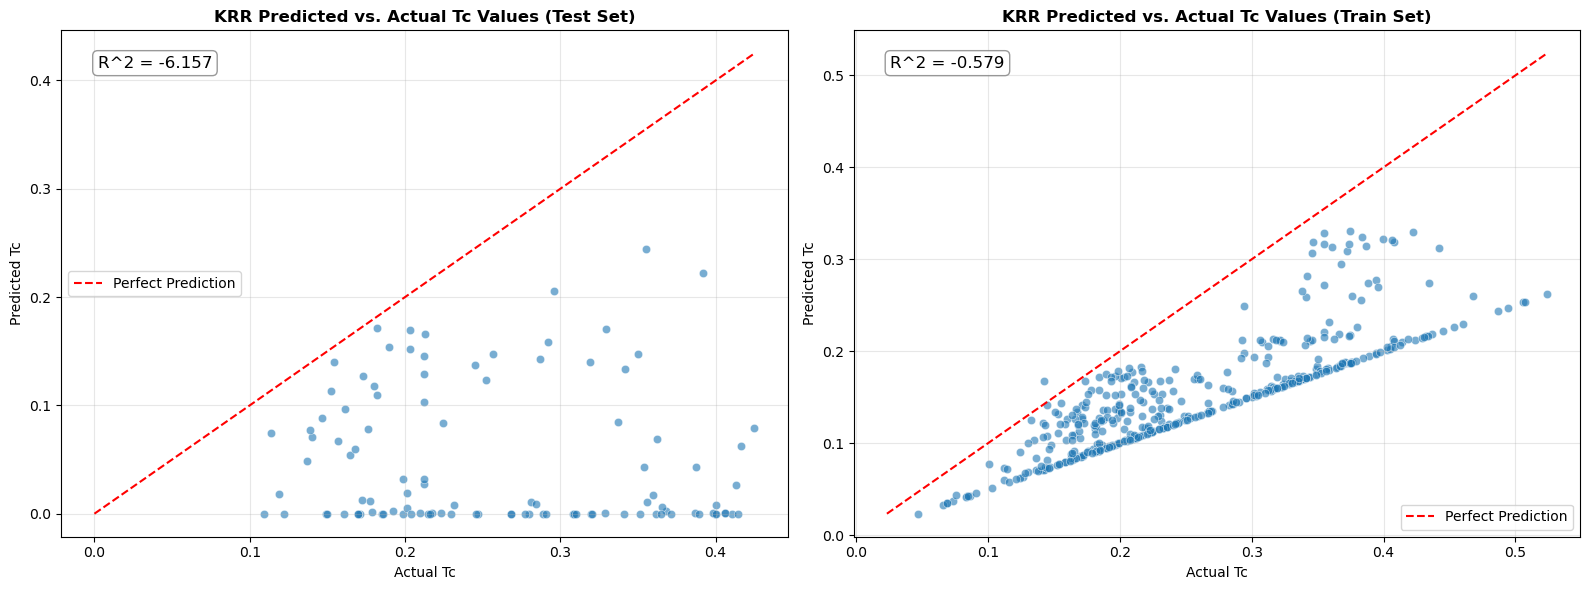

In [54]:
# Get predictions for the test set from KRR model
y_pred_test_krr = krr.predict(df_test[FEATURES_COLS])
y_true_test = df_test[TARGET_COLS] # True values are the same as for LR

# Get predictions for the train set from KRR model
y_pred_train_krr = krr.predict(df_train[FEATURES_COLS])
y_true_train = df_train[TARGET_COLS] # True values are the same as for LR
# Added Tg as a feature
# Calculate R-squared scores for KRR
r2_test_krr = r2_score(y_true_test, y_pred_test_krr)
r2_train_krr = r2_score(y_true_train, y_pred_train_krr)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # 1 row, 2 columns

# Plot for Test Set (KRR)
ax = axes[0]
sns.scatterplot(x=y_true_test, y=y_pred_test_krr, alpha=0.6, ax=ax)
min_val_test = min(y_true_test.min(), y_pred_test_krr.min())
max_val_test = max(y_true_test.max(), y_pred_test_krr.max())
ax.plot([min_val_test, max_val_test], [min_val_test, max_val_test], color='red', linestyle='--', label='Perfect Prediction')
ax.text(0.05, 0.95, f'R^2 = {r2_test_krr:.3f}', transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=1, alpha=0.8))
ax.set_title('KRR Predicted vs. Actual Tc Values (Test Set)', fontweight='bold')
ax.set_xlabel('Actual Tc')
ax.set_ylabel('Predicted Tc')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot for Train Set (KRR)
ax = axes[1]
sns.scatterplot(x=y_true_train, y=y_pred_train_krr, alpha=0.6, ax=ax)
min_val_train = min(y_true_train.min(), y_pred_train_krr.min())
max_val_train = max(y_true_train.max(), y_pred_train_krr.max())
ax.plot([min_val_train, max_val_train], [min_val_train, max_val_train], color='red', linestyle='--', label='Perfect Prediction')
ax.text(0.05, 0.95, f'R^2 = {r2_train_krr:.3f}', transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=1, alpha=0.8))
ax.set_title('KRR Predicted vs. Actual Tc Values (Train Set)', fontweight='bold')
ax.set_xlabel('Actual Tc')
ax.set_ylabel('Predicted Tc')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

Kernel Model (using pipeline)

In [55]:
pipe_Krr = Pipeline(
    [
        ('variance_treshold', VarianceThreshold(1)),
        ('selectkbest', SelectKBest(score_func=f_regression)), # Add SelectKBest for feature selection
        ('scaling', MinMaxScaler()),
        ('krr', KernelRidge(kernel='rbf'))
    ]
)

In [56]:
param_grid_variance_threshold = {
                    'scaling': [None, StandardScaler()],
                    'selectkbest__k': [2, 3, 4, 5,6,7,8,9,10,11,12,13,14], # Number of features to select, given we have 5 initial features
                    'krr__alpha': np.logspace(-3,1,10),
                    'krr__gamma':np.logspace(-3,3,10), # Corrected: 'krr__#fillme' to 'krr__gamma'
                    'variance_treshold__threshold':[0.0, 1e-3, 1e-2, 1e-1, 0.5, 1.0]
            }

random_variance_treshold = RandomizedSearchCV(pipe_Krr, param_distributions=param_grid_variance_threshold, n_iter=20,
                        cv=10, verbose=2, n_jobs=-1)

In [57]:
# Fit the pipeline and run the evaluation
random_variance_treshold.fit(df_train[FEATURES_COLS], df_train[TARGET_COLS])

Fitting 10 folds for each of 20 candidates, totalling 200 fits
[CV] END krr__alpha=3.593813663804626, krr__gamma=0.46415888336127775, scaling=None, selectkbest__k=9, variance_treshold__threshold=1.0; total time=   0.0s
[CV] END krr__alpha=3.593813663804626, krr__gamma=0.46415888336127775, scaling=None, selectkbest__k=9, variance_treshold__threshold=1.0; total time=   0.0s
[CV] END krr__alpha=3.593813663804626, krr__gamma=0.46415888336127775, scaling=None, selectkbest__k=9, variance_treshold__threshold=1.0; total time=   0.0s
[CV] END krr__alpha=0.001, krr__gamma=1000.0, scaling=StandardScaler(), selectkbest__k=12, variance_treshold__threshold=1.0; total time=   0.0s
[CV] END krr__alpha=0.001, krr__gamma=1000.0, scaling=StandardScaler(), selectkbest__k=12, variance_treshold__threshold=1.0; total time=   0.0s
[CV] END krr__alpha=0.001, krr__gamma=1000.0, scaling=StandardScaler(), selectkbest__k=12, variance_treshold__threshold=1.0; total time=   0.0s
[CV] END krr__alpha=0.001, krr__gamma

/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=10. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=10. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=10. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=10. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_sele

[CV] END krr__alpha=0.1668100537200059, krr__gamma=0.004641588833612777, scaling=None, selectkbest__k=10, variance_treshold__threshold=0.01; total time=   0.0s
[CV] END krr__alpha=0.1668100537200059, krr__gamma=0.004641588833612777, scaling=None, selectkbest__k=10, variance_treshold__threshold=0.01; total time=   0.0s
[CV] END krr__alpha=0.1668100537200059, krr__gamma=0.004641588833612777, scaling=None, selectkbest__k=10, variance_treshold__threshold=0.01; total time=   0.0s
[CV] END krr__alpha=0.1668100537200059, krr__gamma=0.004641588833612777, scaling=None, selectkbest__k=10, variance_treshold__threshold=0.01; total time=   0.0s
[CV] END krr__alpha=0.1668100537200059, krr__gamma=0.004641588833612777, scaling=None, selectkbest__k=10, variance_treshold__threshold=0.01; total time=   0.0s
[CV] END krr__alpha=0.1668100537200059, krr__gamma=0.004641588833612777, scaling=None, selectkbest__k=10, variance_treshold__threshold=0.01; total time=   0.0s
[CV] END krr__alpha=0.1668100537200059, 

/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_sele

[CV] END krr__alpha=0.021544346900318832, krr__gamma=46.41588833612773, scaling=None, selectkbest__k=10, variance_treshold__threshold=0.5; total time=   0.0s
[CV] END krr__alpha=0.007742636826811269, krr__gamma=0.001, scaling=None, selectkbest__k=12, variance_treshold__threshold=0.01; total time=   0.0s
[CV] END krr__alpha=0.05994842503189409, krr__gamma=2.154434690031882, scaling=StandardScaler(), selectkbest__k=14, variance_treshold__threshold=0.1; total time=   0.0s
[CV] END krr__alpha=3.593813663804626, krr__gamma=0.1, scaling=None, selectkbest__k=14, variance_treshold__threshold=0.0; total time=   0.0s
[CV] END krr__alpha=1.2915496650148828, krr__gamma=46.41588833612773, scaling=None, selectkbest__k=3, variance_treshold__threshold=0.1; total time=   0.0s
[CV] END krr__alpha=0.007742636826811269, krr__gamma=0.001, scaling=None, selectkbest__k=12, variance_treshold__threshold=0.01; total time=   0.0s
[CV] END krr__alpha=0.05994842503189409, krr__gamma=2.154434690031882, scaling=Stan

/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=14 is greater than n_features=11. All the features will be returned.
  warnings.warn(


,estimator,Pipeline(step...rnel='rbf'))])
,param_distributions,"{'krr__alpha': array([1.0000...00000000e+01]), 'krr__gamma': array([1.0000...00000000e+03]), 'scaling': [None, StandardScaler()], 'selectkbest__k': [2, 3, ...], ...}"
,n_iter,20
,scoring,None
,n_jobs,-1
,refit,True
,cv,10
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [58]:
# Get the best estimator from RandomizedSearchCV
best_krr_pipeline = random_variance_treshold.best_estimator_

print("Best KRR Pipeline Parameters:")
print(random_variance_treshold.best_params_)

# Get the metrics on the train and the test set using the best KRR pipeline
tuned_krr_results_train = linear_regression_metrics(best_krr_pipeline, df_train[FEATURES_COLS], df_train[TARGET_COLS])
tuned_krr_results_test = linear_regression_metrics(best_krr_pipeline, df_test[FEATURES_COLS], df_test[TARGET_COLS])

# Print the results
print("\nTuned Kernel Ridge Regression Results - Train Set:", tuned_krr_results_train)
print("Tuned Kernel Ridge Regression Results - Test Set:", tuned_krr_results_test)

Best KRR Pipeline Parameters:
{'variance_treshold__threshold': 1.0, 'selectkbest__k': 10, 'scaling': StandardScaler(), 'krr__gamma': np.float64(0.1), 'krr__alpha': np.float64(0.001)}

Tuned Kernel Ridge Regression Results - Train Set: {'mae': 0.011917508991924605, 'mse': 0.0003000372914532305, 'max_error': 0.0900601862225393, 'mape': 0.049873649534395444}
Tuned Kernel Ridge Regression Results - Test Set: {'mae': 0.035032449314318335, 'mse': 0.002647264145322258, 'max_error': 0.24907247534112614, 'mape': 0.1398886581271697}


Kernel Visualization

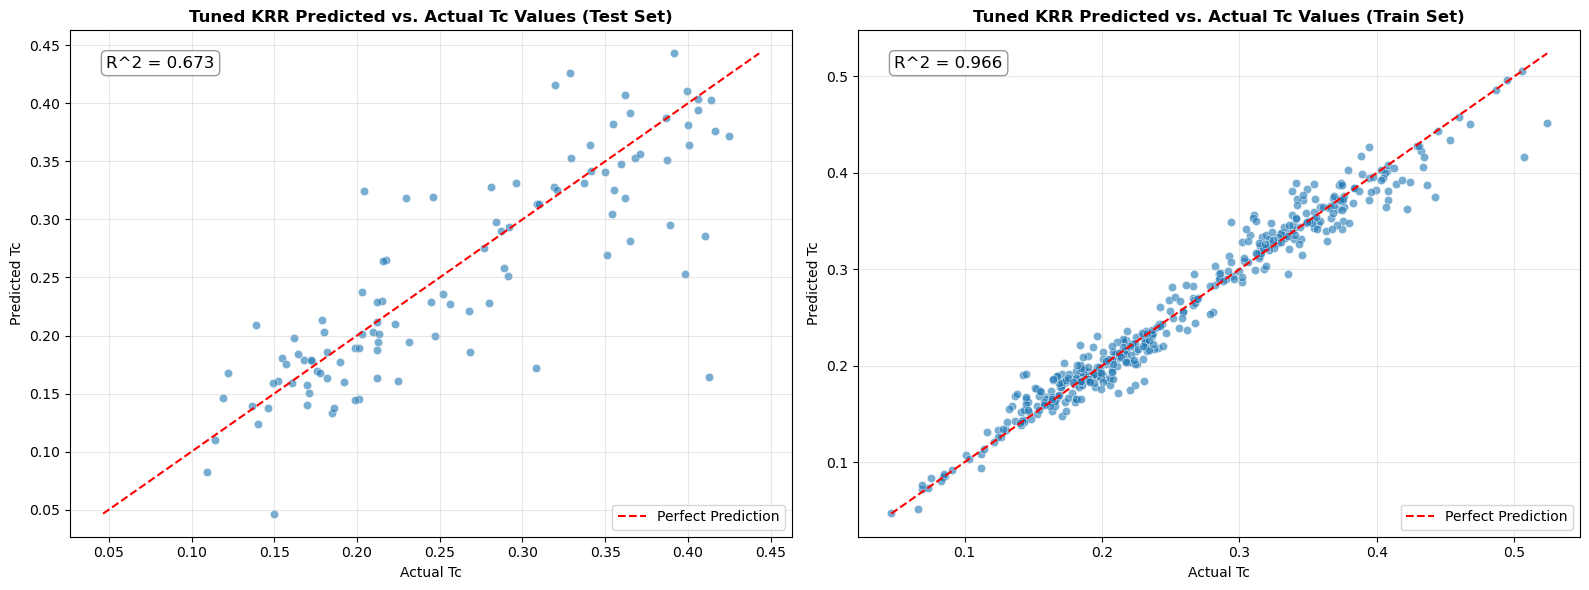

In [59]:
# Get predictions for the test set from the best tuned KRR model
y_pred_test_tuned_krr = best_krr_pipeline.predict(df_test[FEATURES_COLS])
y_true_test = df_test[TARGET_COLS] # True values are the same

# Get predictions for the train set from the best tuned KRR model
y_pred_train_tuned_krr = best_krr_pipeline.predict(df_train[FEATURES_COLS])
y_true_train = df_train[TARGET_COLS] # True values are the same

# Calculate R-squared scores for tuned KRR
r2_test_tuned_krr = r2_score(y_true_test, y_pred_test_tuned_krr)
r2_train_tuned_krr = r2_score(y_true_train, y_pred_train_tuned_krr)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # 1 row, 2 columns

# Plot for Test Set (Tuned KRR)
ax = axes[0]
sns.scatterplot(x=y_true_test, y=y_pred_test_tuned_krr, alpha=0.6, ax=ax)
min_val_test = min(y_true_test.min(), y_pred_test_tuned_krr.min())
max_val_test = max(y_true_test.max(), y_pred_test_tuned_krr.max())
ax.plot([min_val_test, max_val_test], [min_val_test, max_val_test], color='red', linestyle='--', label='Perfect Prediction')
ax.text(0.05, 0.95, f'R^2 = {r2_test_tuned_krr:.3f}', transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=1, alpha=0.8))
ax.set_title('Tuned KRR Predicted vs. Actual Tc Values (Test Set)', fontweight='bold')
ax.set_xlabel('Actual Tc')
ax.set_ylabel('Predicted Tc')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot for Train Set (Tuned KRR)
ax = axes[1]
sns.scatterplot(x=y_true_train, y=y_pred_train_tuned_krr, alpha=0.6, ax=ax)
min_val_train = min(y_true_train.min(), y_pred_train_tuned_krr.min())
max_val_train = max(y_true_train.max(), y_pred_train_tuned_krr.max())
ax.plot([min_val_train, max_val_train], [min_val_train, max_val_train], color='red', linestyle='--', label='Perfect Prediction')
ax.text(0.05, 0.95, f'R^2 = {r2_train_tuned_krr:.3f}', transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=1, alpha=0.8))
ax.set_title('Tuned KRR Predicted vs. Actual Tc Values (Train Set)', fontweight='bold')
ax.set_xlabel('Actual Tc')
ax.set_ylabel('Predicted Tc')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

XGBoost

In [60]:
# Initialize the XGBoost Regressor model
xgb_regressor = xgb.XGBRegressor(objective='reg:squarederror', random_state=RANDOM_SEED)

# Train the model on the training data
xgb_regressor.fit(df_train[FEATURES_COLS], df_train[TARGET_COLS])

# Get the metrics on the train and the test set using the linear_regression_metrics function
xgb_results_train = linear_regression_metrics(xgb_regressor, df_train[FEATURES_COLS], df_train[TARGET_COLS])
xgb_results_test = linear_regression_metrics(xgb_regressor, df_test[FEATURES_COLS], df_test[TARGET_COLS])

# Print the results
print("XGBoost Regression Results - Train Set:", xgb_results_train)
print("XGBoost Regression Results - Test Set:", xgb_results_test)

XGBoost Regression Results - Train Set: {'mae': 0.0010559171166267612, 'mse': 2.4614836643651344e-06, 'max_error': 0.008408972740173326, 'mape': 0.004495978779667334}
XGBoost Regression Results - Test Set: {'mae': 0.032725127719140455, 'mse': 0.0020418188587246074, 'max_error': 0.16780688428878784, 'mape': 0.13383704296545437}


XGBoost Visualization (unoptimized)

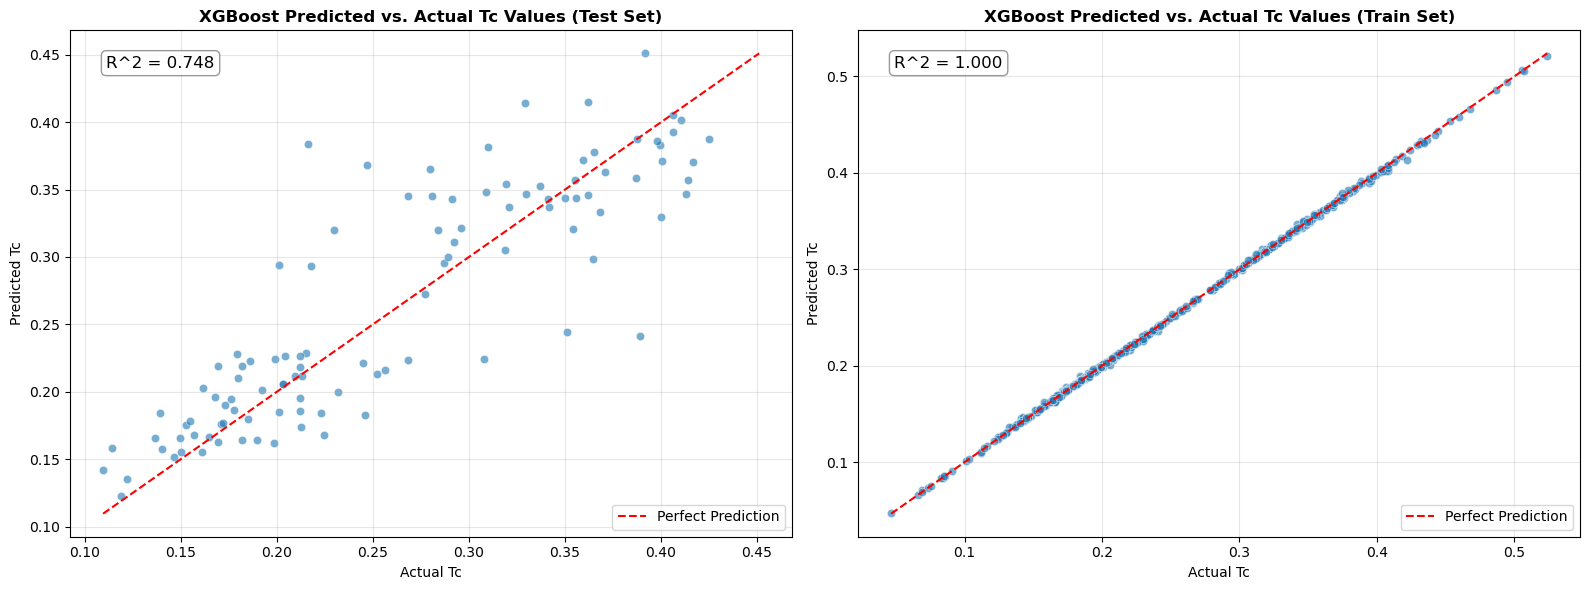

In [62]:
# Get predictions for the test set from XGBoost model
y_pred_test_xgb = xgb_regressor.predict(df_test[FEATURES_COLS])
y_true_test = df_test[TARGET_COLS] # True values are the same as for other models

# Get predictions for the train set from XGBoost model
y_pred_train_xgb = xgb_regressor.predict(df_train[FEATURES_COLS])
y_true_train = df_train[TARGET_COLS] # True values are the same as for other models

# Calculate R-squared scores for XGBoost
r2_test_xgb = r2_score(y_true_test, y_pred_test_xgb)
r2_train_xgb = r2_score(y_true_train, y_pred_train_xgb)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # 1 row, 2 columns

# Plot for Test Set (XGBoost)
ax = axes[0]
sns.scatterplot(x=y_true_test, y=y_pred_test_xgb, alpha=0.6, ax=ax)
min_val_test = min(y_true_test.min(), y_pred_test_xgb.min())
max_val_test = max(y_true_test.max(), y_pred_test_xgb.max())
ax.plot([min_val_test, max_val_test], [min_val_test, max_val_test], color='red', linestyle='--', label='Perfect Prediction')
ax.text(0.05, 0.95, f'R^2 = {r2_test_xgb:.3f}', transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=1, alpha=0.8))
ax.set_title('XGBoost Predicted vs. Actual Tc Values (Test Set)', fontweight='bold')
ax.set_xlabel('Actual Tc')
ax.set_ylabel('Predicted Tc')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot for Train Set (XGBoost)
ax = axes[1]
sns.scatterplot(x=y_true_train, y=y_pred_train_xgb, alpha=0.6, ax=ax)
min_val_train = min(y_true_train.min(), y_pred_train_xgb.min())
max_val_train = max(y_true_train.max(), y_pred_train_xgb.max())
ax.plot([min_val_train, max_val_train], [min_val_train, max_val_train], color='red', linestyle='--', label='Perfect Prediction')
ax.text(0.05, 0.95, f'R^2 = {r2_train_xgb:.3f}', transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=1, alpha=0.8))
ax.set_title('XGBoost Predicted vs. Actual Tc Values (Train Set)', fontweight='bold')
ax.set_xlabel('Actual Tc')
ax.set_ylabel('Predicted Tc')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

XGBoost (using Pipeline)

In [63]:
# Define the pipeline for XGBoost with SelectKBest for feature selection
pipe_XGboost = Pipeline(
    [
        ('variance_threshold', VarianceThreshold()), # Keep this step for variance filtering
        ('selectkbest', SelectKBest(score_func=f_regression)), # Add SelectKBest for feature selection
        ('scaling', StandardScaler()), # Start with StandardScaler as a default scaling option
        ('xgbregressor', xgb.XGBRegressor(objective='reg:squarederror', random_state=RANDOM_SEED))
    ]
)

In [64]:
param_grid_xgboost = {
    'variance_threshold__threshold': [0.0, 1e-4, 1e-3, 1e-2, 1e-1, 0.2, 0.5], # Expanded range
    'selectkbest__k': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13], # Max 13 features
    'scaling': [None, StandardScaler(), MinMaxScaler()],
    'xgbregressor__n_estimators': [100, 200, 400, 600, 800, 1000], # Increased upper bound
    'xgbregressor__learning_rate': [0.005, 0.01, 0.05, 0.1, 0.2, 0.3], # Expanded range
    'xgbregressor__max_depth': [3, 5, 7, 10, 12, 15], # Increased upper bound
    'xgbregressor__min_child_weight': [1, 3, 5, 7, 10, 15], # Increased upper bound
    'xgbregressor__gamma': [0, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8], # Expanded range
    'xgbregressor__subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0], # Expanded range
    'xgbregressor__colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0] # Expanded range
}

random_xgboost_search = RandomizedSearchCV(pipe_XGboost, param_distributions=param_grid_xgboost, n_iter=200,
                        cv=5, verbose=2, n_jobs=-1, random_state=RANDOM_SEED)

In [65]:
# Fit the pipeline and run the evaluation
random_xgboost_search.fit(df_train[FEATURES_COLS], df_train[TARGET_COLS])

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
[CV] END scaling=MinMaxScaler(), selectkbest__k=8, variance_threshold__threshold=0.2, xgbregressor__colsample_bytree=0.8, xgbregressor__gamma=0.8, xgbregressor__learning_rate=0.1, xgbregressor__max_depth=7, xgbregressor__min_child_weight=1, xgbregressor__n_estimators=1000, xgbregressor__subsample=0.6; total time=   0.0s
[CV] END scaling=MinMaxScaler(), selectkbest__k=8, variance_threshold__threshold=0.2, xgbregressor__colsample_bytree=0.8, xgbregressor__gamma=0.8, xgbregressor__learning_rate=0.1, xgbregressor__max_depth=7, xgbregressor__min_child_weight=1, xgbregressor__n_estimators=1000, xgbregressor__subsample=0.6; total time=   0.0s
[CV] END scaling=StandardScaler(), selectkbest__k=5, variance_threshold__threshold=0.001, xgbregressor__colsample_bytree=0.7, xgbregressor__gamma=0.2, xgbregressor__learning_rate=0.01, xgbregressor__max_depth=10, xgbregressor__min_child_weight=1, xgbregressor__n_estimators=800, xgbregressor_

/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_sele


[CV] END scaling=MinMaxScaler(), selectkbest__k=5, variance_threshold__threshold=0.01, xgbregressor__colsample_bytree=0.9, xgbregressor__gamma=0.2, xgbregressor__learning_rate=0.05, xgbregressor__max_depth=7, xgbregressor__min_child_weight=15, xgbregressor__n_estimators=800, xgbregressor__subsample=0.8; total time=   0.1s
[CV] END scaling=MinMaxScaler(), selectkbest__k=6, variance_threshold__threshold=0.1, xgbregressor__colsample_bytree=1.0, xgbregressor__gamma=0, xgbregressor__learning_rate=0.005, xgbregressor__max_depth=10, xgbregressor__min_child_weight=5, xgbregressor__n_estimators=400, xgbregressor__subsample=0.6; total time=   0.2s
[CV] END scaling=MinMaxScaler(), selectkbest__k=12, variance_threshold__threshold=0.5, xgbregressor__colsample_bytree=0.9, xgbregressor__gamma=0.4, xgbregressor__learning_rate=0.2, xgbregressor__max_depth=3, xgbregressor__min_child_weight=5, xgbregressor__n_estimators=1000, xgbregressor__subsample=0.7; total time=   0.0s
[CV] END scaling=MinMaxScaler(

/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_sele

[CV] END scaling=StandardScaler(), selectkbest__k=8, variance_threshold__threshold=0.001, xgbregressor__colsample_bytree=1.0, xgbregressor__gamma=0.05, xgbregressor__learning_rate=0.005, xgbregressor__max_depth=3, xgbregressor__min_child_weight=10, xgbregressor__n_estimators=800, xgbregressor__subsample=0.9; total time=   0.1s
[CV] END scaling=StandardScaler(), selectkbest__k=6, variance_threshold__threshold=0.01, xgbregressor__colsample_bytree=0.8, xgbregressor__gamma=0, xgbregressor__learning_rate=0.3, xgbregressor__max_depth=5, xgbregressor__min_child_weight=3, xgbregressor__n_estimators=1000, xgbregressor__subsample=0.5; total time=   0.1s
[CV] END scaling=MinMaxScaler(), selectkbest__k=4, variance_threshold__threshold=0.1, xgbregressor__colsample_bytree=0.7, xgbregressor__gamma=0.6, xgbregressor__learning_rate=0.005, xgbregressor__max_depth=10, xgbregressor__min_child_weight=10, xgbregressor__n_estimators=400, xgbregressor__subsample=1.0; total time=   0.0s
[CV] END scaling=MinMax

/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_sele

[CV] END scaling=StandardScaler(), selectkbest__k=13, variance_threshold__threshold=0.5, xgbregressor__colsample_bytree=0.9, xgbregressor__gamma=0.6, xgbregressor__learning_rate=0.1, xgbregressor__max_depth=7, xgbregressor__min_child_weight=3, xgbregressor__n_estimators=600, xgbregressor__subsample=0.7; total time=   0.0s
[CV] END scaling=StandardScaler(), selectkbest__k=5, variance_threshold__threshold=0.5, xgbregressor__colsample_bytree=1.0, xgbregressor__gamma=0.8, xgbregressor__learning_rate=0.01, xgbregressor__max_depth=10, xgbregressor__min_child_weight=1, xgbregressor__n_estimators=400, xgbregressor__subsample=1.0; total time=   0.0s
[CV] END scaling=MinMaxScaler(), selectkbest__k=4, variance_threshold__threshold=0.0, xgbregressor__colsample_bytree=0.6, xgbregressor__gamma=0.2, xgbregressor__learning_rate=0.1, xgbregressor__max_depth=12, xgbregressor__min_child_weight=5, xgbregressor__n_estimators=400, xgbregressor__subsample=0.7; total time=   0.0s
[CV] END scaling=StandardScal

/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_sele


[CV] END scaling=MinMaxScaler(), selectkbest__k=12, variance_threshold__threshold=0.1, xgbregressor__colsample_bytree=1.0, xgbregressor__gamma=0.05, xgbregressor__learning_rate=0.01, xgbregressor__max_depth=3, xgbregressor__min_child_weight=10, xgbregressor__n_estimators=400, xgbregressor__subsample=0.6; total time=   0.0s
[CV] END scaling=None, selectkbest__k=2, variance_threshold__threshold=0.0001, xgbregressor__colsample_bytree=0.8, xgbregressor__gamma=0.05, xgbregressor__learning_rate=0.05, xgbregressor__max_depth=12, xgbregressor__min_child_weight=15, xgbregressor__n_estimators=200, xgbregressor__subsample=0.5; total time=   0.0s
[CV] END scaling=StandardScaler(), selectkbest__k=2, variance_threshold__threshold=0.0001, xgbregressor__colsample_bytree=0.5, xgbregressor__gamma=0.2, xgbregressor__learning_rate=0.1, xgbregressor__max_depth=7, xgbregressor__min_child_weight=15, xgbregressor__n_estimators=600, xgbregressor__subsample=1.0; total time=   0.0s
[CV] END scaling=MinMaxScaler

/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_sele


[CV] END scaling=StandardScaler(), selectkbest__k=8, variance_threshold__threshold=0.2, xgbregressor__colsample_bytree=0.5, xgbregressor__gamma=0.6, xgbregressor__learning_rate=0.05, xgbregressor__max_depth=12, xgbregressor__min_child_weight=3, xgbregressor__n_estimators=100, xgbregressor__subsample=0.6; total time=   0.0s
[CV] END scaling=StandardScaler(), selectkbest__k=12, variance_threshold__threshold=0.2, xgbregressor__colsample_bytree=0.6, xgbregressor__gamma=0.1, xgbregressor__learning_rate=0.2, xgbregressor__max_depth=3, xgbregressor__min_child_weight=10, xgbregressor__n_estimators=200, xgbregressor__subsample=0.7; total time=   0.0s
[CV] END scaling=StandardScaler(), selectkbest__k=7, variance_threshold__threshold=0.1, xgbregressor__colsample_bytree=1.0, xgbregressor__gamma=0, xgbregressor__learning_rate=0.1, xgbregressor__max_depth=7, xgbregressor__min_child_weight=15, xgbregressor__n_estimators=800, xgbregressor__subsample=0.7; total time=   0.1s
[CV] END scaling=StandardSc

/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(


[CV] END scaling=StandardScaler(), selectkbest__k=7, variance_threshold__threshold=0.1, xgbregressor__colsample_bytree=1.0, xgbregressor__gamma=0, xgbregressor__learning_rate=0.1, xgbregressor__max_depth=7, xgbregressor__min_child_weight=15, xgbregressor__n_estimators=800, xgbregressor__subsample=0.7; total time=   0.1s
[CV] END scaling=MinMaxScaler(), selectkbest__k=4, variance_threshold__threshold=0.001, xgbregressor__colsample_bytree=0.6, xgbregressor__gamma=0.2, xgbregressor__learning_rate=0.05, xgbregressor__max_depth=12, xgbregressor__min_child_weight=7, xgbregressor__n_estimators=800, xgbregressor__subsample=0.5; total time=   0.0s
[CV] END scaling=None, selectkbest__k=9, variance_threshold__threshold=0.5, xgbregressor__colsample_bytree=1.0, xgbregressor__gamma=0.6, xgbregressor__learning_rate=0.1, xgbregressor__max_depth=3, xgbregressor__min_child_weight=7, xgbregressor__n_estimators=800, xgbregressor__subsample=0.5; total time=   0.0s
[CV] END scaling=None, selectkbest__k=9, v

/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_sele

[CV] END scaling=MinMaxScaler(), selectkbest__k=3, variance_threshold__threshold=0.001, xgbregressor__colsample_bytree=0.5, xgbregressor__gamma=0.2, xgbregressor__learning_rate=0.3, xgbregressor__max_depth=7, xgbregressor__min_child_weight=10, xgbregressor__n_estimators=600, xgbregressor__subsample=0.6; total time=   0.0s
[CV] END scaling=MinMaxScaler(), selectkbest__k=3, variance_threshold__threshold=0.001, xgbregressor__colsample_bytree=0.5, xgbregressor__gamma=0.2, xgbregressor__learning_rate=0.3, xgbregressor__max_depth=7, xgbregressor__min_child_weight=10, xgbregressor__n_estimators=600, xgbregressor__subsample=0.6; total time=   0.0s
[CV] END scaling=None, selectkbest__k=12, variance_threshold__threshold=0.5, xgbregressor__colsample_bytree=1.0, xgbregressor__gamma=0.1, xgbregressor__learning_rate=0.05, xgbregressor__max_depth=3, xgbregressor__min_child_weight=7, xgbregressor__n_estimators=600, xgbregressor__subsample=0.6; total time=   0.0s
[CV] END scaling=MinMaxScaler(), select

/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_sele

[CV] END scaling=None, selectkbest__k=9, variance_threshold__threshold=0.2, xgbregressor__colsample_bytree=1.0, xgbregressor__gamma=0.2, xgbregressor__learning_rate=0.01, xgbregressor__max_depth=15, xgbregressor__min_child_weight=10, xgbregressor__n_estimators=800, xgbregressor__subsample=0.9; total time=   0.0s
[CV] END scaling=MinMaxScaler(), selectkbest__k=13, variance_threshold__threshold=0.2, xgbregressor__colsample_bytree=0.6, xgbregressor__gamma=0.2, xgbregressor__learning_rate=0.01, xgbregressor__max_depth=15, xgbregressor__min_child_weight=15, xgbregressor__n_estimators=100, xgbregressor__subsample=0.5; total time=   0.0s
[CV] END scaling=StandardScaler(), selectkbest__k=9, variance_threshold__threshold=0.1, xgbregressor__colsample_bytree=0.6, xgbregressor__gamma=0.8, xgbregressor__learning_rate=0.1, xgbregressor__max_depth=12, xgbregressor__min_child_weight=7, xgbregressor__n_estimators=600, xgbregressor__subsample=0.8; total time=   0.0s
[CV] END scaling=StandardScaler(), se

/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_sele

[CV] END scaling=StandardScaler(), selectkbest__k=8, variance_threshold__threshold=0.5, xgbregressor__colsample_bytree=0.6, xgbregressor__gamma=0.1, xgbregressor__learning_rate=0.005, xgbregressor__max_depth=10, xgbregressor__min_child_weight=3, xgbregressor__n_estimators=1000, xgbregressor__subsample=0.6; total time=   0.0s
[CV] END scaling=StandardScaler(), selectkbest__k=2, variance_threshold__threshold=0.001, xgbregressor__colsample_bytree=0.6, xgbregressor__gamma=0.1, xgbregressor__learning_rate=0.005, xgbregressor__max_depth=15, xgbregressor__min_child_weight=3, xgbregressor__n_estimators=200, xgbregressor__subsample=0.6; total time=   0.0s
[CV] END scaling=MinMaxScaler(), selectkbest__k=13, variance_threshold__threshold=0.5, xgbregressor__colsample_bytree=0.9, xgbregressor__gamma=0.8, xgbregressor__learning_rate=0.2, xgbregressor__max_depth=7, xgbregressor__min_child_weight=5, xgbregressor__n_estimators=100, xgbregressor__subsample=1.0; total time=   0.0s
[CV] END scaling=MinMax

/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_sele

[CV] END scaling=MinMaxScaler(), selectkbest__k=13, variance_threshold__threshold=0.0001, xgbregressor__colsample_bytree=0.6, xgbregressor__gamma=0.2, xgbregressor__learning_rate=0.005, xgbregressor__max_depth=3, xgbregressor__min_child_weight=5, xgbregressor__n_estimators=200, xgbregressor__subsample=0.8; total time=   0.0s
[CV] END scaling=MinMaxScaler(), selectkbest__k=2, variance_threshold__threshold=0.5, xgbregressor__colsample_bytree=0.7, xgbregressor__gamma=0, xgbregressor__learning_rate=0.1, xgbregressor__max_depth=12, xgbregressor__min_child_weight=1, xgbregressor__n_estimators=400, xgbregressor__subsample=0.9; total time=   0.1s
[CV] END scaling=MinMaxScaler(), selectkbest__k=7, variance_threshold__threshold=0.0, xgbregressor__colsample_bytree=0.5, xgbregressor__gamma=0.05, xgbregressor__learning_rate=0.1, xgbregressor__max_depth=12, xgbregressor__min_child_weight=10, xgbregressor__n_estimators=100, xgbregressor__subsample=0.6; total time=   0.0s
[CV] END scaling=MinMaxScaler

/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_sele

[CV] END scaling=MinMaxScaler(), selectkbest__k=12, variance_threshold__threshold=0.5, xgbregressor__colsample_bytree=0.5, xgbregressor__gamma=0.4, xgbregressor__learning_rate=0.3, xgbregressor__max_depth=5, xgbregressor__min_child_weight=15, xgbregressor__n_estimators=100, xgbregressor__subsample=0.6; total time=   0.0s
[CV] END scaling=MinMaxScaler(), selectkbest__k=4, variance_threshold__threshold=0.2, xgbregressor__colsample_bytree=0.7, xgbregressor__gamma=0.6, xgbregressor__learning_rate=0.01, xgbregressor__max_depth=10, xgbregressor__min_child_weight=1, xgbregressor__n_estimators=400, xgbregressor__subsample=0.7; total time=   0.0s
[CV] END scaling=MinMaxScaler(), selectkbest__k=9, variance_threshold__threshold=0.2, xgbregressor__colsample_bytree=0.8, xgbregressor__gamma=0, xgbregressor__learning_rate=0.3, xgbregressor__max_depth=7, xgbregressor__min_child_weight=10, xgbregressor__n_estimators=200, xgbregressor__subsample=0.8; total time=   0.0s
[CV] END scaling=MinMaxScaler(), s

/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(


[CV] END scaling=None, selectkbest__k=3, variance_threshold__threshold=0.01, xgbregressor__colsample_bytree=0.6, xgbregressor__gamma=0, xgbregressor__learning_rate=0.01, xgbregressor__max_depth=5, xgbregressor__min_child_weight=3, xgbregressor__n_estimators=800, xgbregressor__subsample=0.8; total time=   0.1s
[CV] END scaling=MinMaxScaler(), selectkbest__k=9, variance_threshold__threshold=0.0, xgbregressor__colsample_bytree=0.8, xgbregressor__gamma=0.8, xgbregressor__learning_rate=0.05, xgbregressor__max_depth=5, xgbregressor__min_child_weight=10, xgbregressor__n_estimators=400, xgbregressor__subsample=1.0; total time=   0.1s
[CV] END scaling=MinMaxScaler(), selectkbest__k=8, variance_threshold__threshold=0.01, xgbregressor__colsample_bytree=0.6, xgbregressor__gamma=0.1, xgbregressor__learning_rate=0.1, xgbregressor__max_depth=10, xgbregressor__min_child_weight=5, xgbregressor__n_estimators=1000, xgbregressor__subsample=0.6; total time=   0.1s
[CV] END scaling=MinMaxScaler(), selectkbe

/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=13 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_sele

[CV] END scaling=MinMaxScaler(), selectkbest__k=4, variance_threshold__threshold=0.2, xgbregressor__colsample_bytree=0.8, xgbregressor__gamma=0.05, xgbregressor__learning_rate=0.005, xgbregressor__max_depth=12, xgbregressor__min_child_weight=10, xgbregressor__n_estimators=100, xgbregressor__subsample=0.6; total time=   0.0s
[CV] END scaling=MinMaxScaler(), selectkbest__k=3, variance_threshold__threshold=0.2, xgbregressor__colsample_bytree=0.7, xgbregressor__gamma=0, xgbregressor__learning_rate=0.05, xgbregressor__max_depth=7, xgbregressor__min_child_weight=15, xgbregressor__n_estimators=200, xgbregressor__subsample=1.0; total time=   0.0s
[CV] END scaling=MinMaxScaler(), selectkbest__k=4, variance_threshold__threshold=0.2, xgbregressor__colsample_bytree=0.8, xgbregressor__gamma=0.05, xgbregressor__learning_rate=0.005, xgbregressor__max_depth=12, xgbregressor__min_child_weight=10, xgbregressor__n_estimators=100, xgbregressor__subsample=0.6; total time=   0.0s
[CV] END scaling=None, sele

/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=12 is greater than n_features=11. All the features will be returned.
  warnings.warn(
/home/kevzhu14/miniforge3/envs/myenv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_sele

[CV] END scaling=StandardScaler(), selectkbest__k=9, variance_threshold__threshold=0.0001, xgbregressor__colsample_bytree=0.7, xgbregressor__gamma=0.05, xgbregressor__learning_rate=0.3, xgbregressor__max_depth=12, xgbregressor__min_child_weight=10, xgbregressor__n_estimators=800, xgbregressor__subsample=0.8; total time=   0.0s
[CV] END scaling=None, selectkbest__k=10, variance_threshold__threshold=0.001, xgbregressor__colsample_bytree=0.5, xgbregressor__gamma=0.05, xgbregressor__learning_rate=0.005, xgbregressor__max_depth=5, xgbregressor__min_child_weight=10, xgbregressor__n_estimators=1000, xgbregressor__subsample=0.5; total time=   0.1s
[CV] END scaling=StandardScaler(), selectkbest__k=8, variance_threshold__threshold=0.5, xgbregressor__colsample_bytree=0.5, xgbregressor__gamma=0.1, xgbregressor__learning_rate=0.005, xgbregressor__max_depth=12, xgbregressor__min_child_weight=1, xgbregressor__n_estimators=600, xgbregressor__subsample=0.5; total time=   0.0s
[CV] END scaling=MinMaxSca

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'scaling': [None, StandardScaler(), ...], 'selectkbest__k': [2, 3, ...], 'variance_threshold__threshold': [0.0, 0.0001, ...], 'xgbregressor__colsample_bytree': [0.5, 0.6, ...], ...}"
,n_iter,200
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,101
,error_score,nan


In [66]:
# Get the best estimator from RandomizedSearchCV
best_xgboost_pipeline = random_xgboost_search.best_estimator_

print("Best XGBoost Pipeline Parameters:")
print(random_xgboost_search.best_params_)

# Get the metrics on the train and the test set using the best XGBoost pipeline
tuned_xgb_results_train = linear_regression_metrics(best_xgboost_pipeline, df_train[FEATURES_COLS], df_train[TARGET_COLS])
tuned_xgb_results_test = linear_regression_metrics(best_xgboost_pipeline, df_test[FEATURES_COLS], df_test[TARGET_COLS])

# Print the results
print("\nTuned XGBoost Regression Results - Train Set:", tuned_xgb_results_train)
print("Tuned XGBoost Regression Results - Test Set:", tuned_xgb_results_test)

Best XGBoost Pipeline Parameters:
{'xgbregressor__subsample': 0.5, 'xgbregressor__n_estimators': 1000, 'xgbregressor__min_child_weight': 3, 'xgbregressor__max_depth': 10, 'xgbregressor__learning_rate': 0.05, 'xgbregressor__gamma': 0, 'xgbregressor__colsample_bytree': 0.9, 'variance_threshold__threshold': 0.0001, 'selectkbest__k': 10, 'scaling': MinMaxScaler()}

Tuned XGBoost Regression Results - Train Set: {'mae': 0.0004120111924832933, 'mse': 3.5528436930170324e-07, 'max_error': 0.002952224493026734, 'mape': 0.0018272963416291906}
Tuned XGBoost Regression Results - Test Set: {'mae': 0.029733565020280045, 'mse': 0.0015862179541250908, 'max_error': 0.14136602544784546, 'mape': 0.12666322383268158}


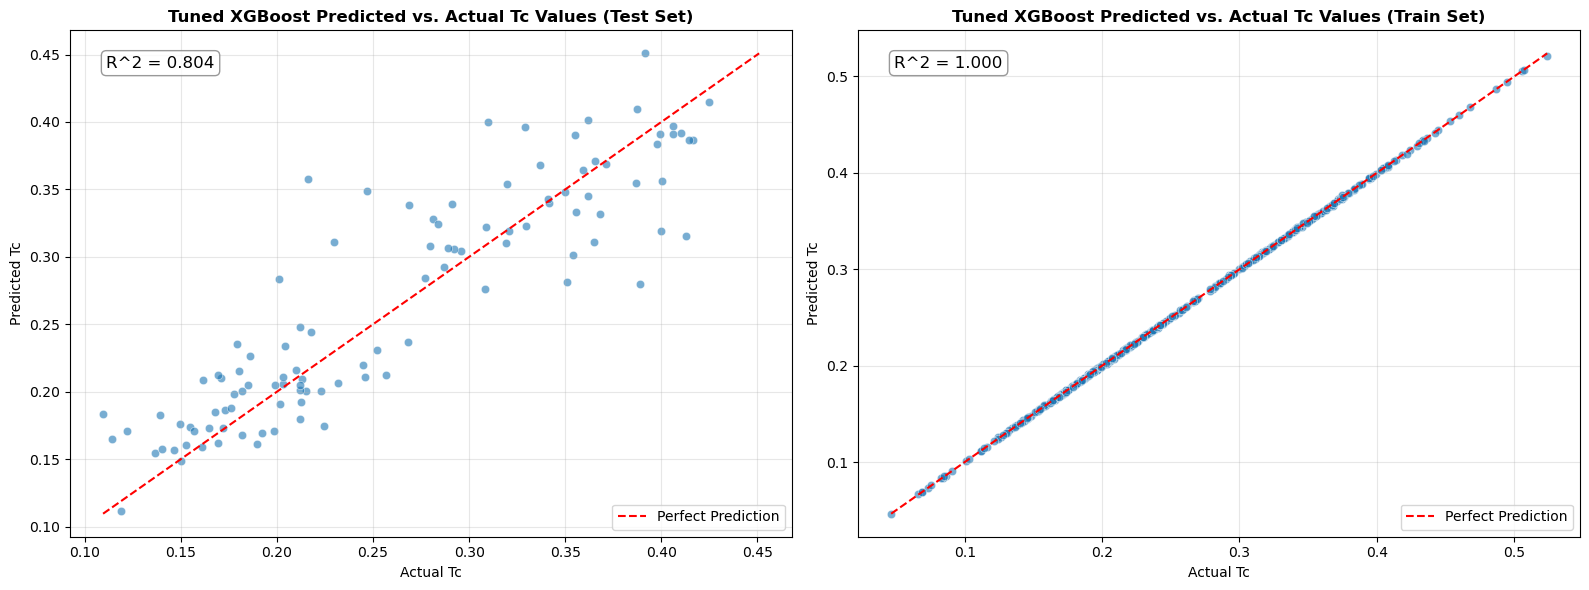

In [67]:
# Get predictions for the test set from the best tuned XGBoost model
y_pred_test_tuned_xgb = best_xgboost_pipeline.predict(df_test[FEATURES_COLS])
y_true_test = df_test[TARGET_COLS] # True values are the same

# Get predictions for the train set from the best tuned XGBoost model
y_pred_train_tuned_xgb = best_xgboost_pipeline.predict(df_train[FEATURES_COLS])
y_true_train = df_train[TARGET_COLS] # True values are the same

# Calculate R-squared scores for tuned XGBoost
r2_test_tuned_xgb = r2_score(y_true_test, y_pred_test_tuned_xgb)
r2_train_tuned_xgb = r2_score(y_true_train, y_pred_train_tuned_xgb)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # 1 row, 2 columns

# Plot for Test Set (Tuned XGBoost)
ax = axes[0]
sns.scatterplot(x=y_true_test, y=y_pred_test_tuned_xgb, alpha=0.6, ax=ax)
min_val_test = min(y_true_test.min(), y_pred_test_tuned_xgb.min())
max_val_test = max(y_true_test.max(), y_pred_test_tuned_xgb.max())
ax.plot([min_val_test, max_val_test], [min_val_test, max_val_test], color='red', linestyle='--', label='Perfect Prediction')
ax.text(0.05, 0.95, f'R^2 = {r2_test_tuned_xgb:.3f}', transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=1, alpha=0.8))
ax.set_title('Tuned XGBoost Predicted vs. Actual Tc Values (Test Set)', fontweight='bold')
ax.set_xlabel('Actual Tc')
ax.set_ylabel('Predicted Tc')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot for Train Set (Tuned XGBoost)
ax = axes[1]
sns.scatterplot(x=y_true_train, y=y_pred_train_tuned_xgb, alpha=0.6, ax=ax)
min_val_train = min(y_true_train.min(), y_pred_train_tuned_xgb.min())
max_val_train = max(y_true_train.max(), y_pred_train_tuned_xgb.max())
ax.plot([min_val_train, max_val_train], [min_val_train, max_val_train], color='red', linestyle='--', label='Perfect Prediction')
ax.text(0.05, 0.95, f'R^2 = {r2_train_tuned_xgb:.3f}', transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='gray', lw=1, alpha=0.8))
ax.set_title('Tuned XGBoost Predicted vs. Actual Tc Values (Train Set)', fontweight='bold')
ax.set_xlabel('Actual Tc')
ax.set_ylabel('Predicted Tc')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

Final Pipeline